## Cálculo de WER

In [5]:
from tools.wer_utils import calculate_wer_from_dataframe
import pandas as pd

full_df = pd.read_csv('dataset_normalized.csv')
wer, df_wer = calculate_wer_from_dataframe(full_df, 'ground_truth.json')
print(f"Global WER: {wer}")
df_wer.to_csv('dataset_wer.csv', index=False)

Global WER: 0.07237244897959183


In [6]:
#muestra las transcripciones con mayor WER para clean
clean_wer_df = df_wer[df_wer['noise'] == 'clean'].sort_values(by='wer', ascending=False)
clean_wer_df[['person', 'audio', 'noise', 'snr', 'provider', 'text_normalized', 'reference', 'wer']].head(20)

,person,audio,noise,snr,provider,text_normalized,reference,wer
1083,p9,4,clean,clean,amazon,genera una proforma parandinacorp incluye dost...,genera una proforma para andinacorp incluye 2 ...,0.571429
3783,p10,4,clean,clean,amazon,genera una proforma para andina incluye dostop...,genera una proforma para andinacorp incluye 2 ...,0.500000
3333,p8,4,clean,clean,amazon,generona proforma para andina incluye 2 core i...,genera una proforma para andinacorp incluye 2 ...,0.500000
2583,p6,4,clean,clean,amazon,genera una proforma para incluye dostope i73 i...,genera una proforma para andinacorp incluye 2 ...,0.500000
333,p1,4,clean,clean,amazon,genera una proforma para incluye 2 i73 impreso...,genera una proforma para andinacorp incluye 2 ...,0.428571
783,p4,4,clean,clean,amazon,genera una proforma parandina incluye 2 core i...,genera una proforma para andinacorp incluye 2 ...,0.428571
5883,p2,4,clean,clean,amazon,genera una proforma para andina corps incluye ...,genera una proforma para andinacorp incluye 2 ...,0.357143
1833,p3,4,clean,clean,amazon,genera una proforma para andinacorp incluye 2 ...,genera una proforma para andinacorp incluye 2 ...,0.285714
4833,p7,4,clean,clean,amazon,genera una proforma para andinacore incluye 2 ...,genera una proforma para andinacorp incluye 2 ...,0.285714
2063,p7,12,clean,clean,azure,creó un cliente con el nombre julián antonio p...,crea un nuevo cliente con el nombre julián ant...,0.230769


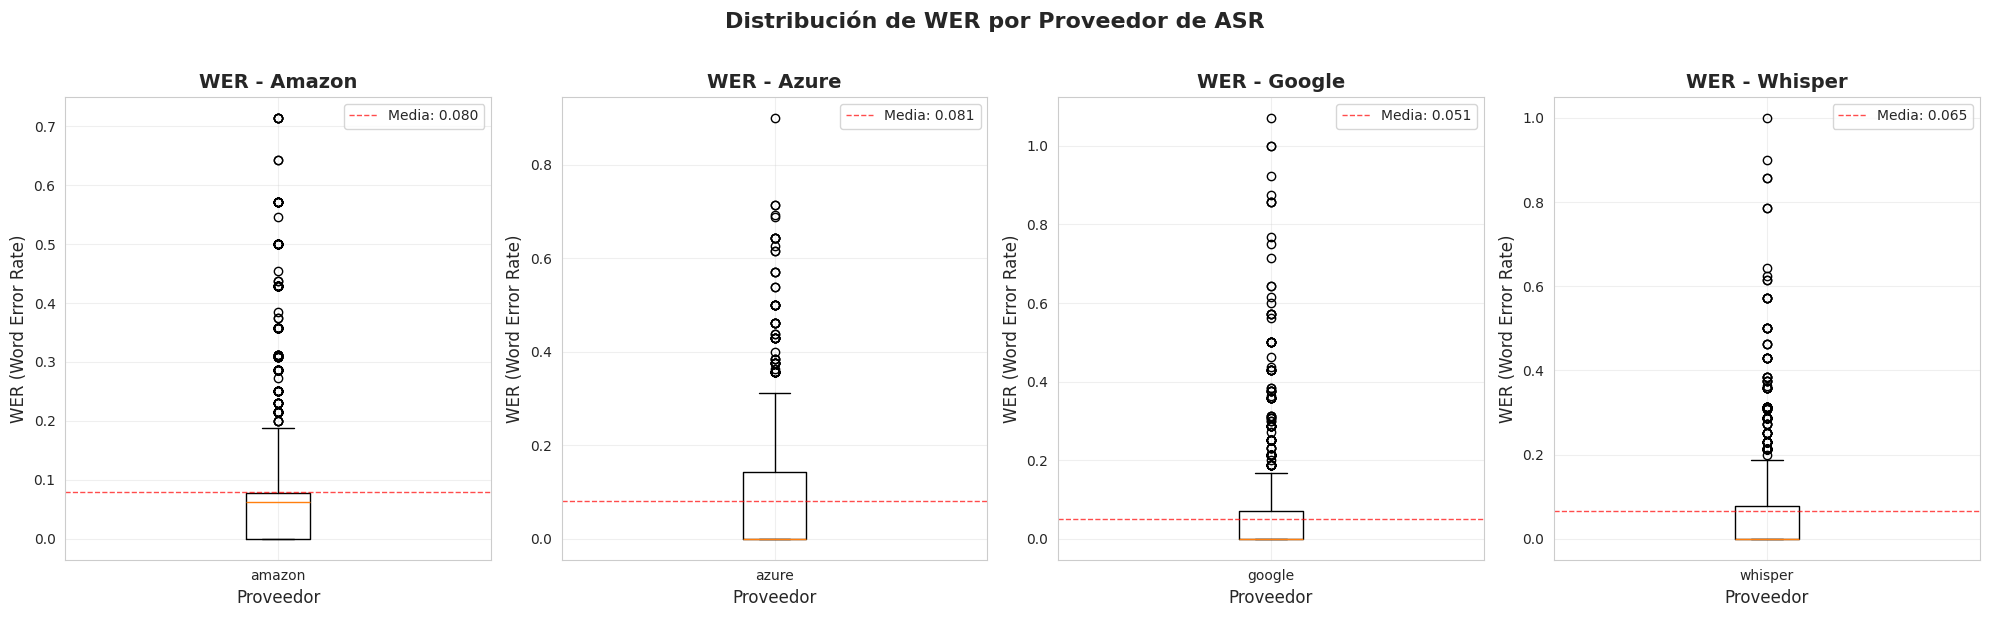


Estadísticas de WER por Proveedor:

AMAZON:
  Media:    0.0796
  Mediana:  0.0625
  Q1 (25%): 0.0000
  Q3 (75%): 0.0769
  Mínimo:   0.0000
  Máximo:   0.7143
  Desv. Est: 0.1243
  Muestras: 1500

AZURE:
  Media:    0.0809
  Mediana:  0.0000
  Q1 (25%): 0.0000
  Q3 (75%): 0.1429
  Mínimo:   0.0000
  Máximo:   0.9000
  Desv. Est: 0.1196
  Muestras: 1500

GOOGLE:
  Media:    0.0513
  Mediana:  0.0000
  Q1 (25%): 0.0000
  Q3 (75%): 0.0714
  Mínimo:   0.0000
  Máximo:   1.0714
  Desv. Est: 0.1192
  Muestras: 1500

WHISPER:
  Media:    0.0647
  Mediana:  0.0000
  Q1 (25%): 0.0000
  Q3 (75%): 0.0769
  Mínimo:   0.0000
  Máximo:   1.0000
  Desv. Est: 0.1157
  Muestras: 1500


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo de seaborn para gráficos más atractivos
sns.set_style("whitegrid")

# Obtener la lista de proveedores únicos
providers = df_wer['provider'].unique()

# Crear una figura con subplots para cada proveedor
fig, axes = plt.subplots(1, len(providers), figsize=(5*len(providers), 6))

# Crear un boxplot para cada proveedor
for idx, provider in enumerate(sorted(providers)):
    # Filtrar datos por proveedor
    provider_data = df_wer[df_wer['provider'] == provider]['wer']
    
    # Crear el boxplot
    axes[idx].boxplot(provider_data, tick_labels=[provider])
    axes[idx].set_title(f'WER - {provider.capitalize()}', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('WER (Word Error Rate)', fontsize=12)
    axes[idx].set_xlabel('Proveedor', fontsize=12)
    axes[idx].grid(True, alpha=0.3)
    
    # Agregar estadísticas básicas
    mean_wer = provider_data.mean()
    median_wer = provider_data.median()
    axes[idx].axhline(y=mean_wer, color='r', linestyle='--', linewidth=1, alpha=0.7, label=f'Media: {mean_wer:.3f}')
    axes[idx].legend()

plt.suptitle('Distribución de WER por Proveedor de ASR', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Mostrar estadísticas descriptivas por proveedor
print("\nEstadísticas de WER por Proveedor:")
for provider in sorted(providers):
    provider_data = df_wer[df_wer['provider'] == provider]['wer']
    print(f"\n{provider.upper()}:")
    print(f"  Media:    {provider_data.mean():.4f}")
    print(f"  Mediana:  {provider_data.median():.4f}")
    print(f"  Q1 (25%): {provider_data.quantile(0.25):.4f}")
    print(f"  Q3 (75%): {provider_data.quantile(0.75):.4f}")
    print(f"  Mínimo:   {provider_data.min():.4f}")
    print(f"  Máximo:   {provider_data.max():.4f}")
    print(f"  Desv. Est: {provider_data.std():.4f}")
    print(f"  Muestras: {len(provider_data)}")

Tabla Comparativa: Rendimiento Global con Intervalos de Confianza


Motor,WER Global,IC 95% Inf,IC 95% Sup
google,5.29%,4.68%,5.93%
whisper,6.78%,6.21%,7.41%
azure,8.42%,7.85%,9.06%
amazon,8.46%,7.82%,9.11%


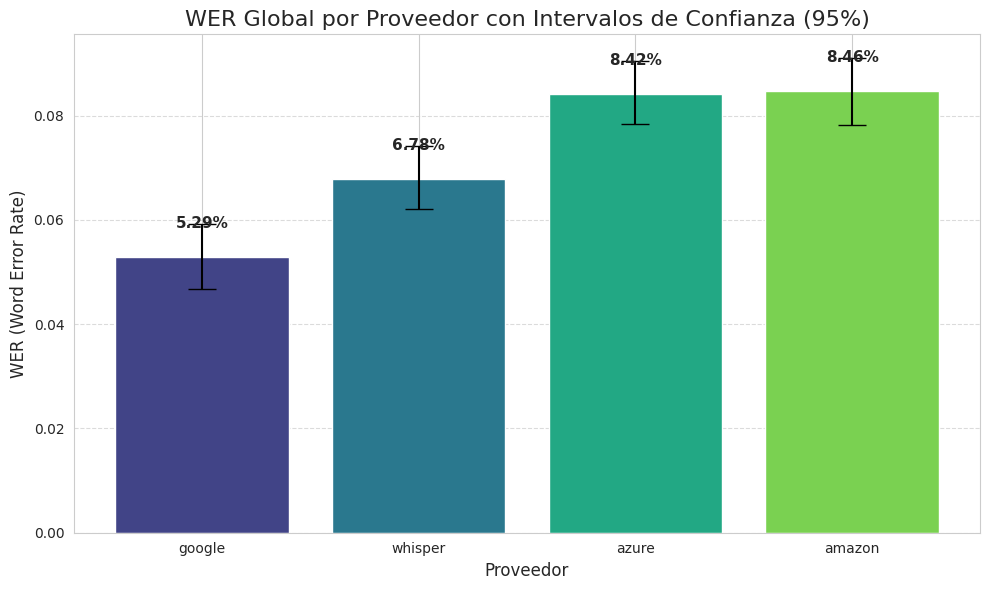


 Análisis Estadístico de Significancia 
Test de Friedman: Estadístico=334.5658, p-value=3.2767e-72
>> Diferencias significativas encontradas. Realizando post-hoc (Wilcoxon + Bonferroni)...


,Comparación,p-value original,p-value adj (Bonferroni),Significativo
0,amazon vs azure,1.237132e-02,7.422793e-02,False
1,amazon vs google,1.143916e-26,6.863499e-26,True
2,amazon vs whisper,8.363424e-07,5.018054e-06,True
3,azure vs google,6.388845e-38,3.833307e-37,True
4,azure vs whisper,1.963362e-13,1.178017e-12,True
5,google vs whisper,2.206342e-14,1.323805e-13,True


In [8]:
import numpy as np
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Bootstrap para Intervalos de Confianza ---
def bootstrap_wer_ci(df, n_bootstraps=1000, confidence_level=0.95):
    """Calcula el intervalo de confianza del WER usando bootstrap."""
    wer_values = []
    errors = df['errors'].values
    words = df['reference_words'].values
    n_samples = len(df)
    rng = np.random.default_rng(42)
    
    for _ in range(n_bootstraps):
        indices = rng.integers(0, n_samples, n_samples)
        total_errors = errors[indices].sum()
        total_words = words[indices].sum()
        wer = total_errors / total_words if total_words > 0 else 0.0
        wer_values.append(wer)
        
    alpha = (1 - confidence_level) / 2
    lower = np.percentile(wer_values, alpha * 100)
    upper = np.percentile(wer_values, (1 - alpha) * 100)
    return lower, upper

# Agrupar por proveedor y calcular totales
summary_df = df_wer.groupby('provider').agg(
    total_errors=('errors', 'sum'),
    total_words=('reference_words', 'sum')
).reset_index()

# Calcular WER Global
summary_df['wer_global'] = summary_df['total_errors'] / summary_df['total_words']

# Calcular CIs
ci_results = {}
for provider, group in df_wer.groupby('provider'):
    lower, upper = bootstrap_wer_ci(group)
    ci_results[provider] = (lower, upper)

summary_df['ci_lower'] = summary_df['provider'].map(lambda x: ci_results[x][0])
summary_df['ci_upper'] = summary_df['provider'].map(lambda x: ci_results[x][1])

# Renombrar columnas
summary_table = summary_df.rename(columns={
    'provider': 'Motor',
    'wer_global': 'WER Global',
    'total_words': 'Total Palabras',
    'total_errors': 'Total Errores',
    'ci_lower': 'IC 95% Inf',
    'ci_upper': 'IC 95% Sup'
})

summary_table = summary_table.sort_values('WER Global')

print("Tabla Comparativa: Rendimiento Global con Intervalos de Confianza")
display(summary_table[['Motor', 'WER Global', 'IC 95% Inf', 'IC 95% Sup']].style.format({
    'WER Global': '{:.2%}',
    'IC 95% Inf': '{:.2%}',
    'IC 95% Sup': '{:.2%}'
}).hide(axis='index'))

# --- 2. Gráfico de Barras con Intervalos de Confianza ---
plt.figure(figsize=(10, 6))
yerr = [
    summary_table['WER Global'] - summary_table['IC 95% Inf'],
    summary_table['IC 95% Sup'] - summary_table['WER Global']
]
bars = plt.bar(summary_table['Motor'], summary_table['WER Global'], capsize=10, 
               yerr=yerr, color=sns.color_palette("viridis", len(summary_table)))
plt.title('WER Global por Proveedor con Intervalos de Confianza (95%)', fontsize=16)
plt.ylabel('WER (Word Error Rate)', fontsize=12)
plt.xlabel('Proveedor', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{height:.2%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# --- 3. Análisis Estadístico (Friedman + Wilcoxon) ---
print("\n Análisis Estadístico de Significancia ")
# Crear ID único para pivotar: person + audio + noise + snr
df_wer['unique_id'] = df_wer['person'].astype(str) + '_' + df_wer['audio'].astype(str) + '_' + df_wer['noise'].astype(str) + '_' + df_wer['snr'].astype(str)
pivot_wer = df_wer.pivot(index='unique_id', columns='provider', values='wer').dropna()

stat, p_value = stats.friedmanchisquare(*[pivot_wer[col] for col in pivot_wer.columns])
print(f"Test de Friedman: Estadístico={stat:.4f}, p-value={p_value:.4e}")

if p_value < 0.05:
    print(">> Diferencias significativas encontradas. Realizando post-hoc (Wilcoxon + Bonferroni)...")
    comparisons = []
    p_values = []
    import itertools
    pairs = list(itertools.combinations(pivot_wer.columns, 2))
    n_comparisons = len(pairs)
    for p1, p2 in pairs:
        stat_w, p_w = stats.wilcoxon(pivot_wer[p1], pivot_wer[p2])
        comparisons.append(f"{p1} vs {p2}")
        p_values.append(p_w)
    
    p_adjusted = [min(1.0, p * n_comparisons) for p in p_values]
    reject = [p < 0.05 for p in p_adjusted]
    results_stats = pd.DataFrame({
        'Comparación': comparisons,
        'p-value original': p_values,
        'p-value adj (Bonferroni)': p_adjusted,
        'Significativo': reject
    })
    display(results_stats)
else:
    print(">> No se encontraron diferencias significativas.")

In [9]:
import matplotlib.pyplot as plt
import pandas as pd


# Definir el orden correcto de los niveles de SNR
snr_order = ['clean','10dB', '5dB', '0dB']

# Preparar los datos: calcular WER promedio por provider y SNR
# Normalizar los valores de SNR para asegurar consistencia
# df_wer['snr'] = df_wer['snr'].astype(str).str.lower().str.replace('db', 'dB')

# Reemplazar 'nan' por 'clean' si es necesario
# df_wer.loc[df_wer['snr'] == 'nan', 'snr'] = 'clean'

# Agrupar por provider y snr para calcular el WER correctamente
grouped_wer = df_wer.groupby(['provider', 'snr']).agg(
    total_errors=('errors', 'sum'),
    total_reference_words=('reference_words', 'sum')
).reset_index()

# Calcular el WER para cada grupo
grouped_wer['wer'] = grouped_wer['total_errors'] / grouped_wer['total_reference_words']

wer_by_provider_snr = grouped_wer[['provider', 'snr', 'wer']]


# Obtener lista de proveedores únicos
providers = sorted(df_wer['provider'].unique())
print("Providers found:", providers)
display(wer_by_provider_snr)


Providers found: ['amazon', 'azure', 'google', 'whisper']


,provider,snr,wer
0,amazon,0dB,0.133163
1,amazon,10dB,0.058673
2,amazon,5dB,0.070408
3,amazon,clean,0.059694
4,azure,0dB,0.157823
5,azure,10dB,0.045918
6,azure,5dB,0.067517
7,azure,clean,0.028061
8,google,0dB,0.124830
9,google,10dB,0.016667


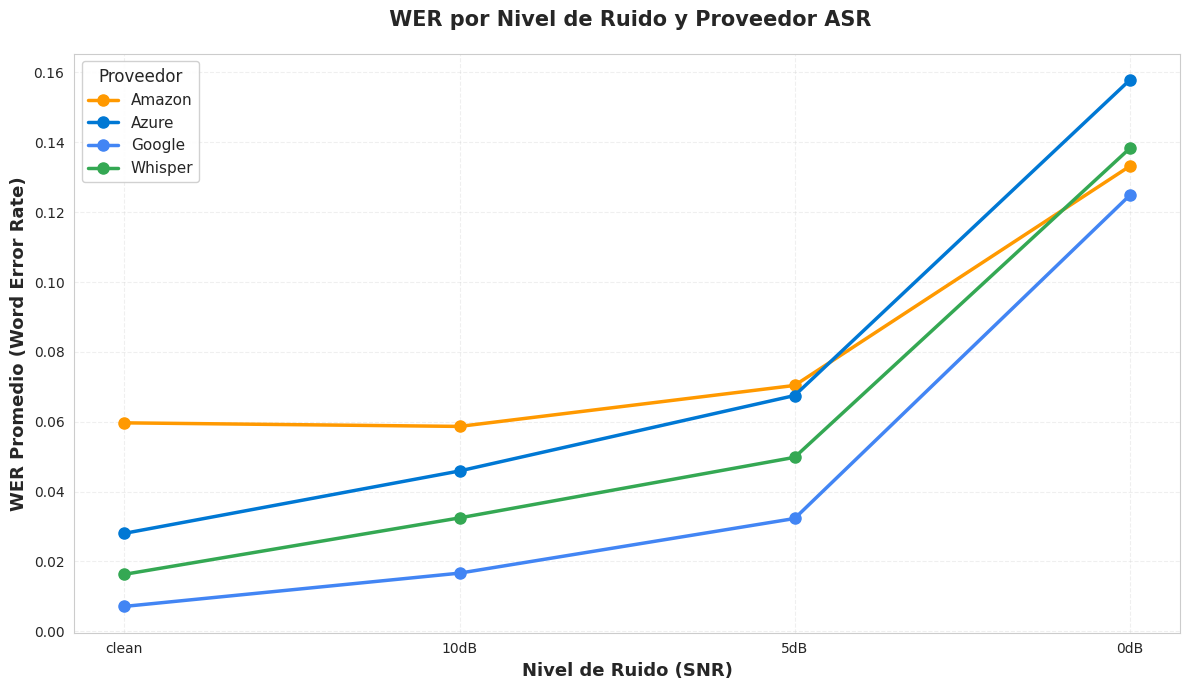


Tabla Comparativa de WER por Escenario y Degradación:


Motor,clean,10dB,5dB,0dB,Degradación (Delta)
amazon,5.97%,5.87%,7.04%,13.32%,+123.08%
azure,2.81%,4.59%,6.75%,15.78%,+462.42%
google,0.71%,1.67%,3.23%,12.48%,+1647.62%
whisper,1.63%,3.25%,4.98%,13.83%,+746.87%


In [10]:
# Configurar el tamaño de la figura explícitamente para esta celda
plt.figure(figsize=(12, 7))

# Definir colores para cada proveedor
colors = {
    'google': '#4285F4',   # Azul Google
    'azure': '#0078D4',    # Azul Azure
    'amazon': '#FF9900',   # Naranja Amazon
    'whisper': '#34A853'    # Verde
}

# Crear el gráfico de líneas
for provider in providers:
    # Filtrar datos para este proveedor
    provider_data = wer_by_provider_snr[wer_by_provider_snr['provider'] == provider]
    
    # Crear un DataFrame con todos los niveles de SNR para asegurar continuidad
    provider_full = pd.DataFrame({'snr': snr_order})
    provider_full = provider_full.merge(provider_data, on='snr', how='left')
    
    # Graficar la línea
    plt.plot(provider_full['snr'], 
             provider_full['wer'], 
             marker='o', 
             linewidth=2.5, 
             markersize=8,
             label=provider.capitalize(),
             color=colors.get(provider, None),
             linestyle='-')

# Configurar el gráfico
plt.xlabel('Nivel de Ruido (SNR)', fontsize=13, fontweight='bold')
plt.ylabel('WER Promedio (Word Error Rate)', fontsize=13, fontweight='bold')
plt.title(' WER por Nivel de Ruido y Proveedor ASR', 
          fontsize=15, fontweight='bold', pad=20)

# Configurar leyenda
plt.legend(title='Proveedor', fontsize=11, title_fontsize=12, 
           loc='best', framealpha=0.9)

# Configurar grid
plt.grid(True, alpha=0.3, linestyle='--')

# Ajustar layout
plt.tight_layout()
plt.show()

# --- Generar Tabla Comparativa Solicitada ---

# Pivotar la tabla: Filas=Provider, Columnas=SNR
detailed_table = wer_by_provider_snr.pivot(index='provider', 
                                           columns='snr', 
                                           values='wer')

# Asegurar el orden de las columnas de SNR
columns_order = [c for c in snr_order if c in detailed_table.columns]
detailed_table = detailed_table[columns_order]

# Calcular Degradación (Delta)
# Se calcula como el incremento porcentual del WER desde 'clean' hasta '0dB'
if 'clean' in detailed_table.columns and '0dB' in detailed_table.columns:
    detailed_table['Degradación (Delta)'] = (detailed_table['0dB'] - detailed_table['clean']) / detailed_table['clean']

# Resetear índice y renombrar columna de proveedor
detailed_table = detailed_table.reset_index().rename(columns={'provider': 'Motor'})

# Mostrar tabla formateada
print("\nTabla Comparativa de WER por Escenario y Degradación:")
display(detailed_table.style.format({
    'clean': '{:.2%}',
    '10dB': '{:.2%}',
    '5dB': '{:.2%}',
    '0dB': '{:.2%}',
    'Degradación (Delta)': '{:+.2%}'
}).hide(axis='index').set_properties(**{
    'text-align': 'center',
    'padding': '8px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold')]}
]))

Recalculando WER con desglose de errores...


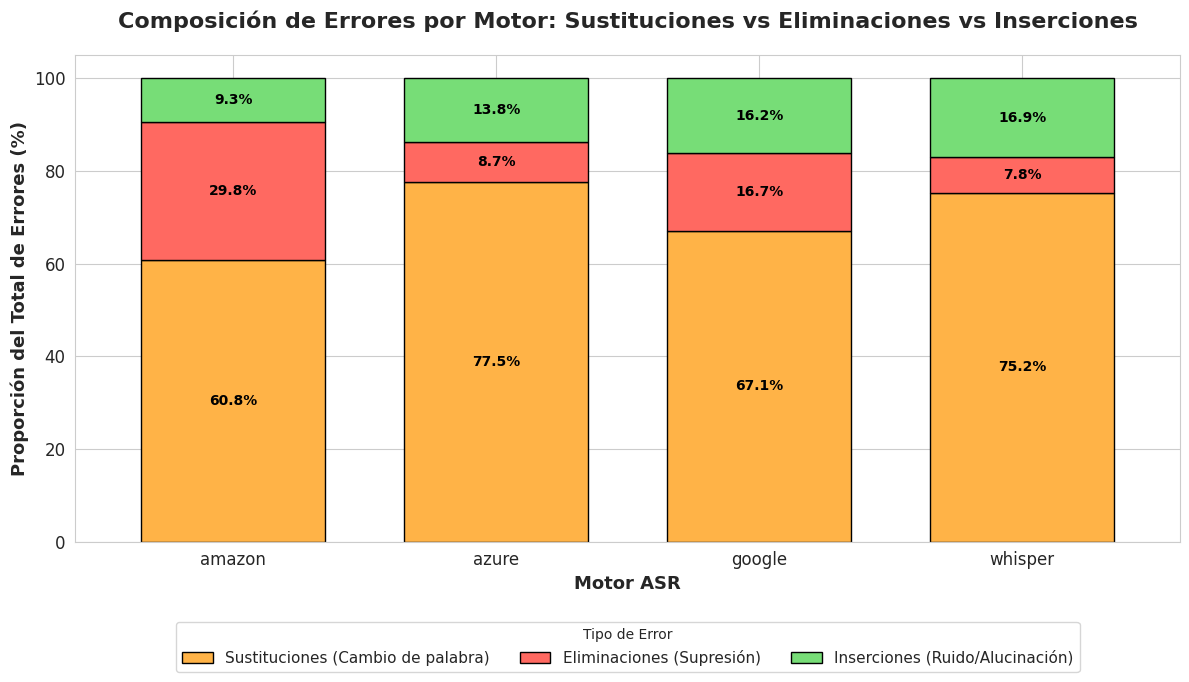


Desglose de Errores (Cantidad y Porcentaje):


,substitutions,deletions,insertions,substitutions (%),deletions (%),insertions (%)
provider,,,,,,
amazon,1009.000000,495.000000,155.000000,60.8,29.8,9.3
azure,1279.000000,144.000000,227.000000,77.5,8.7,13.8
google,695.000000,173.000000,168.000000,67.1,16.7,16.2
whisper,1000.000000,104.000000,225.000000,75.2,7.8,16.9


In [11]:
import matplotlib.pyplot as plt
import pandas as pd
from tools.wer_utils import calculate_wer_from_dataframe

print("Recalculando WER con desglose de errores...")
wer_global, df_detailed = calculate_wer_from_dataframe(full_df, 'ground_truth.json')

# 2. Agrupar por proveedor y sumar componentes de error
error_components = ['substitutions', 'deletions', 'insertions']
error_breakdown = df_detailed.groupby('provider')[error_components].sum()

# 3. Calcular porcentajes (Normalizar al 100% de los errores totales de cada proveedor)
error_breakdown['total_errors'] = error_breakdown.sum(axis=1)
error_breakdown_pct = error_breakdown[error_components].div(error_breakdown['total_errors'], axis=0) * 100

# 4. Graficar Barras Apiladas al 100%
ax = error_breakdown_pct.plot(kind='bar', stacked=True, figsize=(12, 7), 
                              color=['#FFB347', '#FF6961', '#77DD77'], # Naranja (S), Rojo (D), Verde (I)
                              edgecolor='black', width=0.7)

# Configuración del gráfico
plt.title('Composición de Errores por Motor: Sustituciones vs Eliminaciones vs Inserciones', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Motor ASR', fontsize=13, fontweight='bold')
plt.ylabel('Proporción del Total de Errores (%)', fontsize=13, fontweight='bold')
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)

# Configurar leyenda
plt.legend(title='Tipo de Error', labels=['Sustituciones (Cambio de palabra)', 'Eliminaciones (Supresión)', 'Inserciones (Ruido/Alucinación)'], 
           loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=11)

# Añadir etiquetas de porcentaje en el centro de las barras
for c in ax.containers:
    # Filtrar etiquetas para barras muy pequeñas
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 3 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', color='black', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Mostrar tabla de datos absolutos y porcentuales
print("\nDesglose de Errores (Cantidad y Porcentaje):")
display(pd.concat([error_breakdown[error_components], error_breakdown_pct.add_suffix(' (%)')], axis=1).style.format("{:.1f}", subset=error_breakdown_pct.columns.map(lambda x: x + ' (%)')))

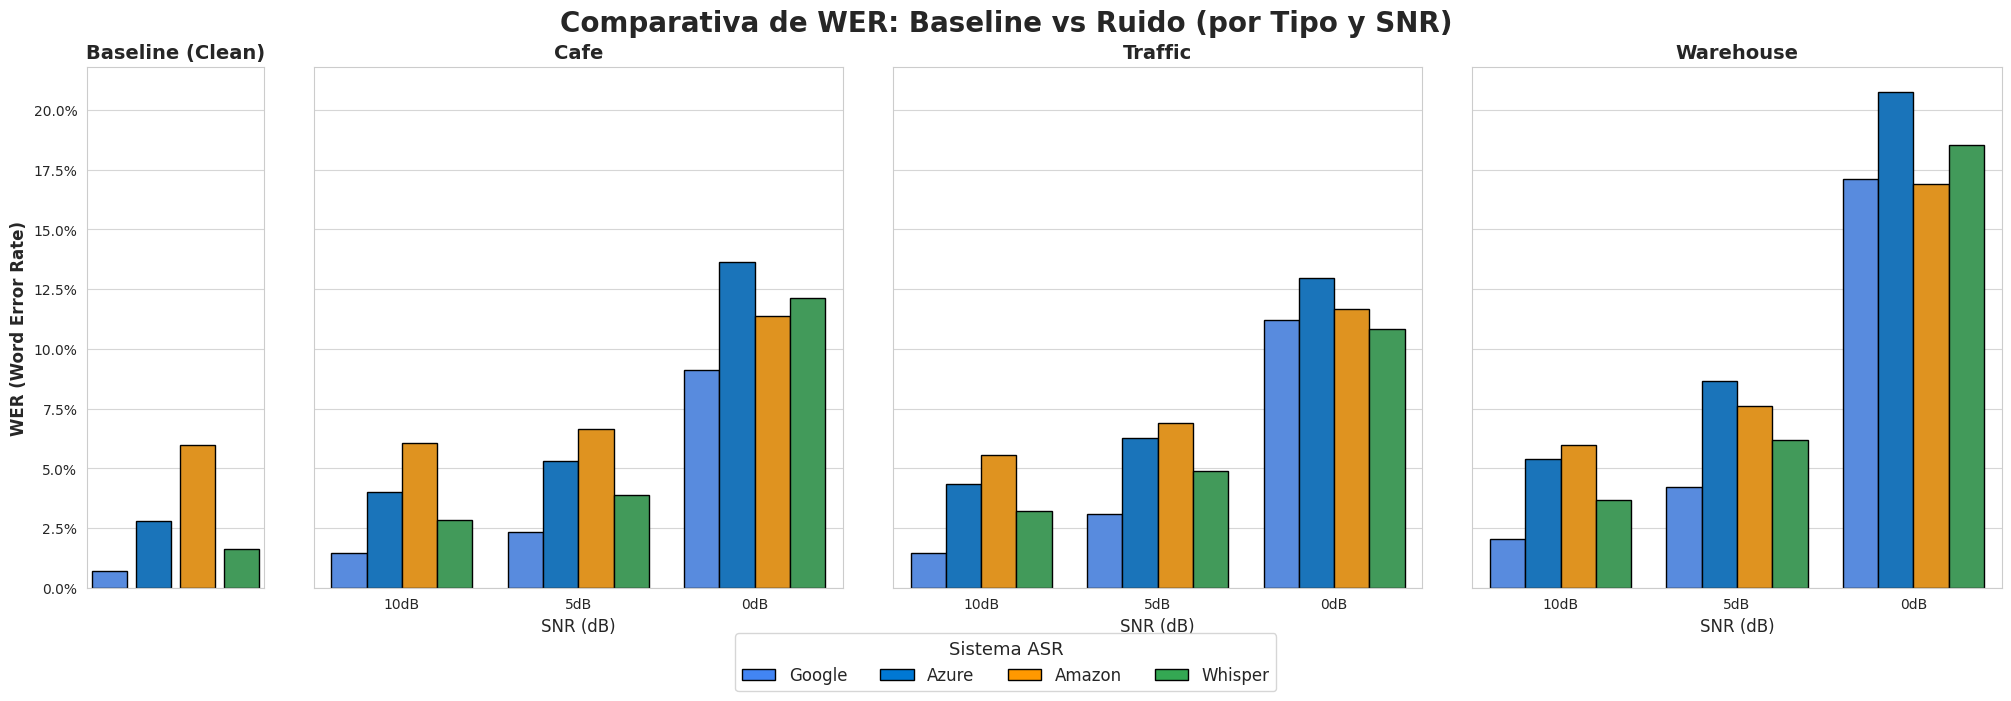

Tabla Resumen de WER por Ruido, SNR y Proveedor:


provider           amazon     azure    google   whisper
noise     snr                                          
cafe      0dB    0.113776  0.136224  0.091327  0.121429
          10dB   0.060714  0.040306  0.014796  0.028571
          5dB    0.066327  0.053061  0.023469  0.038776
clean     clean  0.059694  0.028061  0.007143  0.016327
traffic   0dB    0.116837  0.129592  0.112245  0.108163
          10dB   0.055612  0.043367  0.014796  0.032143
          5dB    0.068878  0.062755  0.031122  0.048980
warehouse 0dB    0.168878  0.207653  0.170918  0.185204
          10dB   0.059694  0.054082  0.020408  0.036735
          5dB    0.076020  0.086735  0.042347  0.061735

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.patches as mpatches
from matplotlib.ticker import PercentFormatter

# 1. Preparar los datos unificados
# Agrupar por provider, noise y snr
unified_wer = df_wer.groupby(['provider', 'noise', 'snr']).agg(
    total_errors=('errors', 'sum'),
    total_reference_words=('reference_words', 'sum')
).reset_index()

# Calcular WER
unified_wer['wer'] = unified_wer['total_errors'] / unified_wer['total_reference_words']

# Configuración de estilos
providers = ['google', 'azure', 'amazon', 'whisper']
colors = {'google': '#4285F4', 'azure': '#0078D4', 'amazon': '#FF9900', 'whisper': '#34A853'}
snr_levels_noisy = ['10dB', '5dB', '0dB']
noises = sorted([n for n in unified_wer['noise'].unique() if n != 'clean'])

# Crear figura con GridSpec para diseño asimétrico
fig = plt.figure(figsize=(20, 6), layout='constrained')
gs = fig.add_gridspec(1, 4, width_ratios=[1, 3, 3, 3], wspace=0.1)

# --- 1. Panel Clean (Baseline) ---
ax_clean = fig.add_subplot(gs[0])
clean_data = unified_wer[unified_wer['noise'] == 'clean']

sns.barplot(data=clean_data, x='provider', y='wer', hue='provider', order=providers, palette=colors, ax=ax_clean, edgecolor='black', legend=False)

ax_clean.set_title("Baseline (Clean)", fontsize=14, fontweight='bold')
ax_clean.set_xlabel("")
ax_clean.set_ylabel("WER (Word Error Rate)", fontsize=12, fontweight='bold')
ax_clean.tick_params(axis='x', bottom=False, labelbottom=False) # Ocultar etiquetas x para limpieza

# --- 2. Paneles de Ruido ---
axes_noisy = []
for i, noise in enumerate(noises):
    ax = fig.add_subplot(gs[i+1], sharey=ax_clean)
    axes_noisy.append(ax)
    
    noise_data = unified_wer[unified_wer['noise'] == noise]
    
    sns.barplot(data=noise_data, x='snr', y='wer', hue='provider', 
                hue_order=providers, order=snr_levels_noisy, 
                palette=colors, ax=ax, edgecolor='black')
    
    ax.set_title(noise.capitalize(), fontsize=14, fontweight='bold')
    ax.set_xlabel("SNR (dB)", fontsize=12)
    ax.set_ylabel("")
    ax.get_legend().remove()

# --- 3. Ajustes Finales ---
# Formato porcentaje en eje Y
for ax in [ax_clean] + axes_noisy:
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.grid(True, axis='y', linestyle='-', alpha=0.8, linewidth=0.8)

# Ocultar eje Y en gráficos de ruido
for ax in axes_noisy:
    plt.setp(ax.get_yticklabels(), visible=False)

# Título global
fig.suptitle('Comparativa de WER: Baseline vs Ruido (por Tipo y SNR)', fontsize=20, fontweight='bold', y=1.05)

# Leyenda única
legend_patches = [mpatches.Patch(facecolor=colors[p], label=p.capitalize(), edgecolor='black') for p in providers]
fig.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=4, fontsize=12, title="Sistema ASR", title_fontsize=13)

plt.show()

# Mostrar tabla resumen opcional
print("Tabla Resumen de WER por Ruido, SNR y Proveedor:")
pivot_table = unified_wer.pivot_table(index=['noise', 'snr'], columns='provider', values='wer')
display(pivot_table)